In [1]:
import os
# os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"

from tree_search import *
from tree_analysis import *
%load_ext autoreload
%autoreload 2

In [17]:
data_folder = "../../monkey_4iar/analysis/data/processed/harry/modeling/2023-02-20"
fold_idx = 0
index = 1

train_data = pd.read_csv(f"{data_folder}/split_{fold_idx}.csv")
trial = train_data.iloc[index]

In [18]:
black_, white_, move_= trial.black, trial.white, trial.move
board = fourbynine_board(fourbynine_pattern(int(black_)), fourbynine_pattern(int(white_)))
actual_move = int(move_).bit_length() - 1

           Parameter :       lo      plo       x0      phi       hi
   pruning_threshold :    0.100    1.000    3.000    6.000   10.000
       stopping_prob :    0.010    0.100    0.300    1.000    1.000
        feature_drop :    0.000    0.000    0.300    0.500    1.000
          lapse_rate :    0.050    0.050    0.100    0.500    1.000
           opp_scale :    0.000    0.200    1.000    4.000    5.000
       center_weight :  -10.000   -5.000    0.400    5.000   10.000
                1IAR :  -10.000   -5.000   -0.500   15.000   20.000
            2IAR_CON :  -10.000   -5.000    2.000   15.000   20.000
            2IAR_DIS :  -10.000   -5.000   -0.900   15.000   20.000
            3IAR_CON :  -10.000   -5.000    6.000   15.000   20.000
            3IAR_DIS :  -10.000   -5.000    4.000   15.000   20.000
                4IAR :  -10.000   -5.000   15.000   15.000   20.000


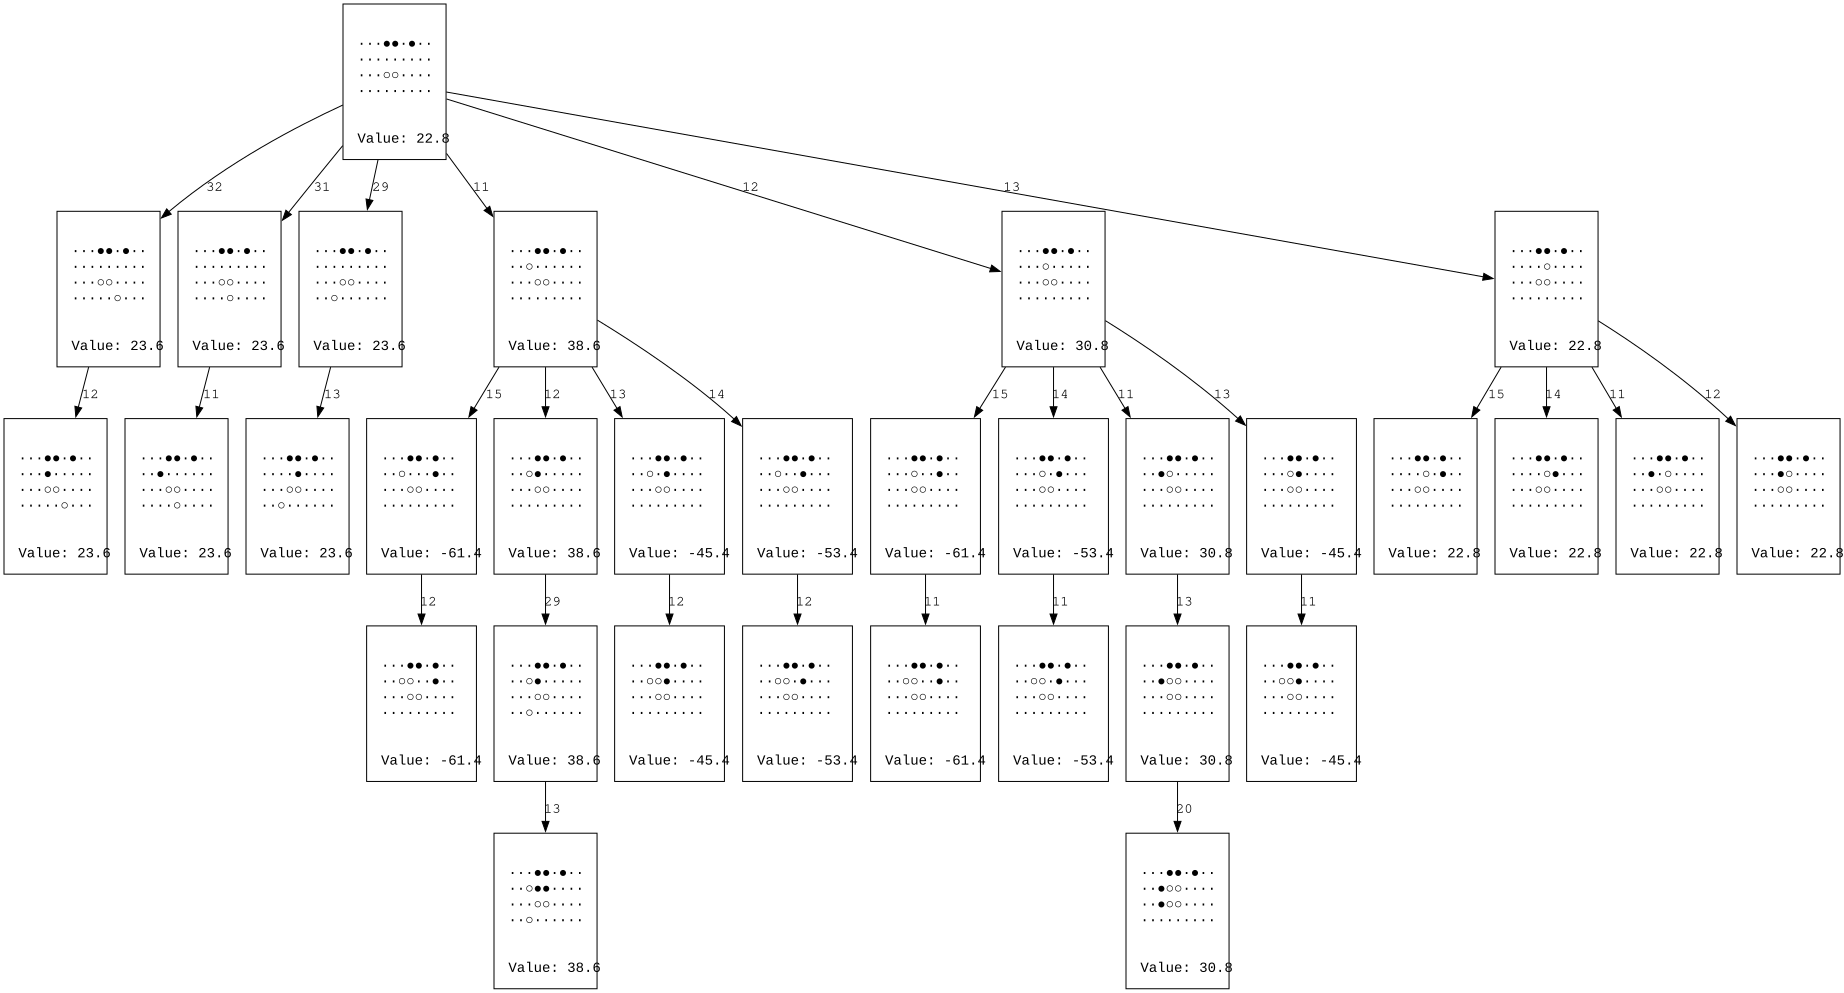

In [26]:
self = TreeSearch()
params = {'pruning_threshold': 0.001,
 'stopping_prob': 0.25,
 'feature_drop': 0.0,
 'lapse_rate': 0.0,
 'opp_scale': 0.1,
 'center_weight': 0.0,
 '1IAR': 0.0,
 '2IAR_CON': 8.0,
 '2IAR_DIS': 2.0,
 '3IAR_CON': 0.0,
 '3IAR_DIS': 0.0,
 '4IAR': 0.0}

self.set_params(np.array(list(params.values())))
heuristic = self.heuristic
heuristic.set_noise_enabled(False)
search = fourbynine.NInARowBestFirstSearch(heuristic, board)
search.complete_search()
root = search.get_tree()
tree_to_graphviz(root)

           Parameter :       lo      plo       x0      phi       hi
   pruning_threshold :    0.100    1.000    3.000    6.000   10.000
        feature_drop :    0.000    0.000    0.300    0.500    1.000
          lapse_rate :    0.050    0.050    0.100    0.500    1.000
           opp_scale :    0.000    0.200    1.000    4.000    5.000
       center_weight :  -10.000   -5.000    0.400    5.000   10.000
                1IAR :  -10.000   -5.000   -0.500   15.000   20.000
            2IAR_CON :  -10.000   -5.000    2.000   15.000   20.000
            2IAR_DIS :  -10.000   -5.000   -0.900   15.000   20.000
            3IAR_CON :  -10.000   -5.000    6.000   15.000   20.000
            3IAR_DIS :  -10.000   -5.000    4.000   15.000   20.000
                4IAR :  -10.000   -5.000   15.000   15.000   20.000


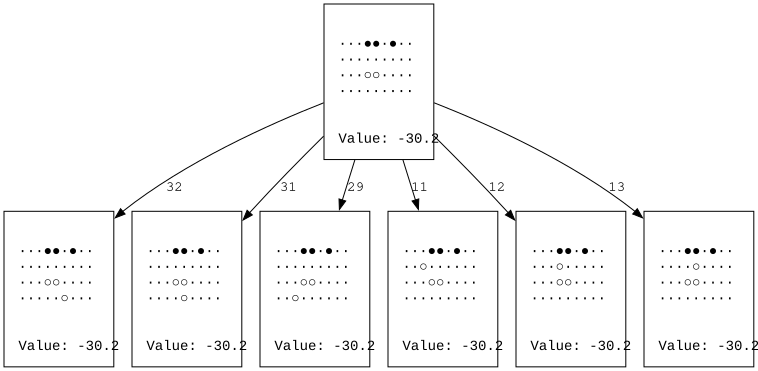

In [24]:
self = MyopicTS()
params = {'pruning_threshold': 0.001,
 'feature_drop': 0.0,
 'lapse_rate': 0.0,
 'opp_scale': 0.1,
 'center_weight': 0.0,
 '1IAR': 0.0,
 '2IAR_CON': 8.0,
 '2IAR_DIS': 2.0,
 '3IAR_CON': 0.0,
 '3IAR_DIS': 0.0,
 '4IAR': 0.0}

self.set_params(np.array(list(params.values())))
heuristic = self.heuristic
heuristic.set_noise_enabled(False)
search = fourbynine.NInARowBestFirstSearch(heuristic, board)
search.complete_search()
root = search.get_tree()
tree_to_graphviz(root)

Text(0.5, 1.0, 'Tree depth, mean = 2.57, std = 1.27')

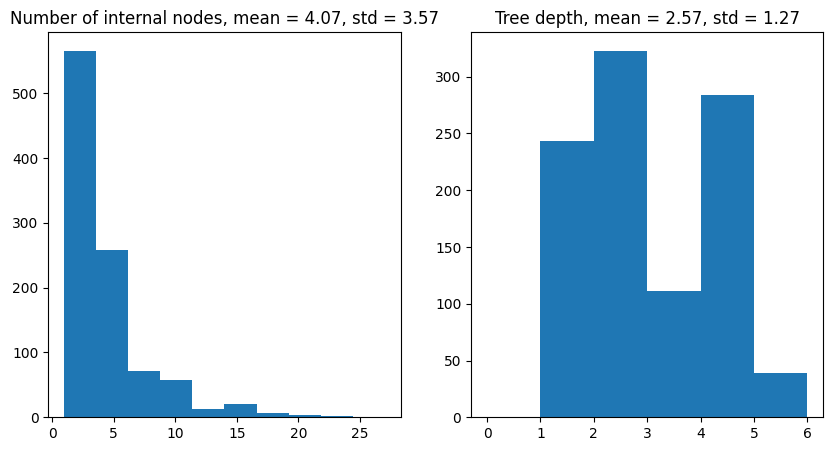

In [9]:
import matplotlib.pyplot as plt
depths = []
n_expansions = []
for _ in range(1000):
    search = fourbynine.NInARowBestFirstSearch(heuristic, board)
    search.complete_search()
    root = search.get_tree()
    tree_to_graphviz(root)
    depths.append(get_max_depth(root))
    n_expansions.append(root.get_num_internal_nodes())

fig, axes = plt.subplots(1, 2, figsize = (10, 5))
axes[0].hist(n_expansions)
axes[0].set_title(f"Number of internal nodes, mean = {np.mean(n_expansions):.2f}, std = {np.std(n_expansions):.2f}")
axes[1].hist(depths, bins = np.arange(0, max(depths) + 1))
axes[1].set_title(f"Tree depth, mean = {np.mean(depths):.2f}, std = {np.std(depths):.2f}")

In [ ]:
self.heuristic.get_best_move(search.get_tree()).board_position

In [ ]:
node = root

hist = np.zeros(36)
for _ in range (100): 
    search = fourbynine.NInARowBestFirstSearch(heuristic, board)
    search.complete_search()
    root = search.get_tree()
    pv = get_principal_variation(root)
    hist[np.array(pv)] += 1 # note that this only works if all moves in pv are unique, which must be true in 4IAR



In [ ]:
import matplotlib.pyplot as plt
plt.imshow(hist.reshape(4, 9), cmap = "Blues")

In [ ]:
hist = get_visits(root, use_paths = True)
plt.imshow(hist.reshape(4, 9))


In [ ]:
hist = np.zeros(36)
for _ in range (500): 
    search = fourbynine.NInARowBestFirstSearch(heuristic, board)
    search.complete_search()
    root = search.get_tree()
    hist += get_visits(root, use_paths = True)

In [ ]:
plt.imshow(hist.reshape(4, 9))


In [ ]:
pv